<h1>FFNN From Scratch</h1>
<h2>Regularization Analysis</h2>

<h3>Configure Root</h3>

In [1]:
import sys
from pathlib import Path as path

root = path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

<h3>Import Library</h3>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.model.layers import FFNN
from src.model.activations import Activation
from src.model.loss import Loss
from src.model.optimizer import GradientDescent
from src.model.initializer import Initializer
from src.utils.data_loader import DataLoader
from utils.visualization import Visualizer


<h3>Importing Data</h3>

In [3]:
loader = DataLoader('../data/datasetml_2026.csv')
loader.load()
loader.eda()
loader.split(train_ratio=0.8, random_seed=42)
loader.preprocess()
loader.split_val(val_size=0.2, random_state=42)

X_train, y_train = loader.get_train()
X_val, y_val   = loader.get_val()
X_test, y_test  = loader.get_test()

X_train = np.asarray(X_train,dtype=np.float64)
X_val = np.asarray(X_val,dtype=np.float64)
X_test = np.asarray(X_test,dtype=np.float64)
y_train = np.asarray(y_train,dtype=np.float64)
y_val = np.asarray(y_val,dtype=np.float64)
y_test = np.asarray(y_test,dtype=np.float64)

INPUT_DIM = X_train.shape[1]
print(f'Input dim: {INPUT_DIM}')
print(f'Train: {X_train.shape}')
print(f'Val: {X_val.shape}')
print(f'Test: {X_test.shape}')

[DataLoader] Berhasil memuat 10000 baris dan 12 kolom dari '../data/datasetml_2026.csv'

[DataLoader] Kolom: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']

                          Head Dataset                           


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed



                      Datatypes Dataset===                       
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 9

None


                     Informasi Missing Data                      


...

np.int64(0)


                  Informasi Outlier (Metode IQR                  
cgpa: 83 outliers
backlogs: 29 outliers
internship_count: 662 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 36 outliers

                   Informasi Distribusi Target                   


placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64

placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64

[DataLoader] Data di-split: 8000 Train, 2000 Test



               Informasi Outlier Setelah Clipping                
cgpa: 0 outliers
backlogs: 0 outliers
internship_count: 0 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 0 outliers
[DataLoader] Preprocessing selesai.
[DataLoader] X_train : (6400, 21) | y_train : (6400,)
[DataLoader] X_val   : (1600, 21)   | y_val   : (1600,)
Input dim: 21
Train: (6400, 21)
Val: (1600, 21)
Test: (2000, 21)


<h3>Initialize Model</h3>

In [4]:
model1 = FFNN(
    input_dim=INPUT_DIM, 
    hidden_dim=[128, 64], 
    output_dim=1, 
    hidden_activation='relu', 
    output_activation='sigmoid', 
    loss_name='bce', 
    init_method='he', 
    seed=42
)

model2 = FFNN(
    input_dim=INPUT_DIM, 
    hidden_dim=[128, 64], 
    output_dim=1, 
    hidden_activation='relu', 
    output_activation='sigmoid', 
    loss_name='bce', 
    init_method='he', 
    seed=42
)

model3 = FFNN(
    input_dim=INPUT_DIM, 
    hidden_dim=[128, 64], 
    output_dim=1, 
    hidden_activation='relu', 
    output_activation='sigmoid', 
    loss_name='bce', 
    init_method='he', 
    seed=42
)

[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42


<h3>Train Models</h3>

In [5]:
optimizer1 = GradientDescent(lr=0.01, reg_type=None,  lam=0.0)
optimizer2 = GradientDescent(lr=0.01, reg_type='l1',  lam=0.001)
optimizer3 = GradientDescent(lr=0.01, reg_type='l2',  lam=0.001)
viz = Visualizer()

epochs = 50
batch_size = 32

models = [
    ('Tanpa Reg', model1, optimizer1),
    ('L1 Regularization', model2, optimizer2),
    ('L2 Regularization', model3, optimizer3)
]

results = {}
for name, model, optimizer, in models:
    viz.print_section_term(f"Training {name}")
    for epoch in range(1, epochs + 1):
        metrics = model.train_epoch(
            X_train, y_train,
            optimizer=optimizer,
            batch_size=batch_size,
            x_val=X_val,
            y_val=y_val,
        )
        print(f"Epoch {epoch:03d}/{epochs}"
              + f"Train loss: {metrics['train_loss']:.4f}, acc: {metrics['train_acc']:.4f}"
              + f"Validation loss: {metrics['val_loss']:.4f}, acc: {metrics['val_acc']:.4f}")
    results[name] = {
        'model'  : model,
        'history': model.get_training_history(),
    }

print('\n=== Test Accuracy ===')
for name, model in results.items():
    y_pred = model['model'].predict(X_test)
    acc    = float(np.mean(y_pred == y_test.ravel()))
    print(f'  {name:15s}  |  Test Acc: {acc:.4f} ({acc*100:.2f}%)')


                       Training Tanpa Reg                        
Epoch 001/50Train loss: 0.5928, acc: 0.7392Validation loss: 0.5151, acc: 0.7594
Epoch 002/50Train loss: 0.5167, acc: 0.7541Validation loss: 0.4944, acc: 0.7612
Epoch 003/50Train loss: 0.5027, acc: 0.7542Validation loss: 0.4914, acc: 0.7612
Epoch 004/50Train loss: 0.4985, acc: 0.7584Validation loss: 0.4861, acc: 0.7594
Epoch 005/50Train loss: 0.4964, acc: 0.7583Validation loss: 0.4846, acc: 0.7600
Epoch 006/50Train loss: 0.4945, acc: 0.7595Validation loss: 0.4838, acc: 0.7638
Epoch 007/50Train loss: 0.4937, acc: 0.7575Validation loss: 0.4887, acc: 0.7700
Epoch 008/50Train loss: 0.4928, acc: 0.7609Validation loss: 0.4825, acc: 0.7619
Epoch 009/50Train loss: 0.4911, acc: 0.7603Validation loss: 0.4823, acc: 0.7631
Epoch 010/50Train loss: 0.4904, acc: 0.7609Validation loss: 0.4817, acc: 0.7644
Epoch 011/50Train loss: 0.4896, acc: 0.7544Validation loss: 0.4925, acc: 0.7562
Epoch 012/50Train loss: 0.4890, acc: 0.7620Validation

## Plot : Loss Curve

[Visualizer] saved in ../results/reg_loss.png


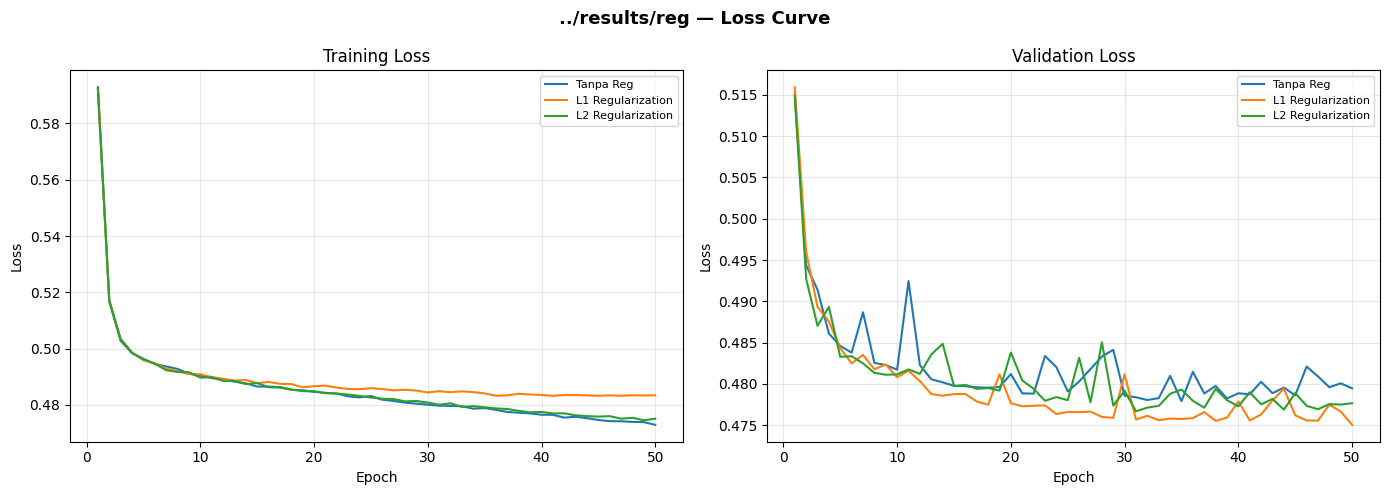

In [6]:
viz.plot_comparison(
    results     = results,
    mode        = 'loss',
    save_prefix = '../results/reg',
)

## Plot: Weight Distribution

[Visualizer] saved in ../results/reg_weights.png


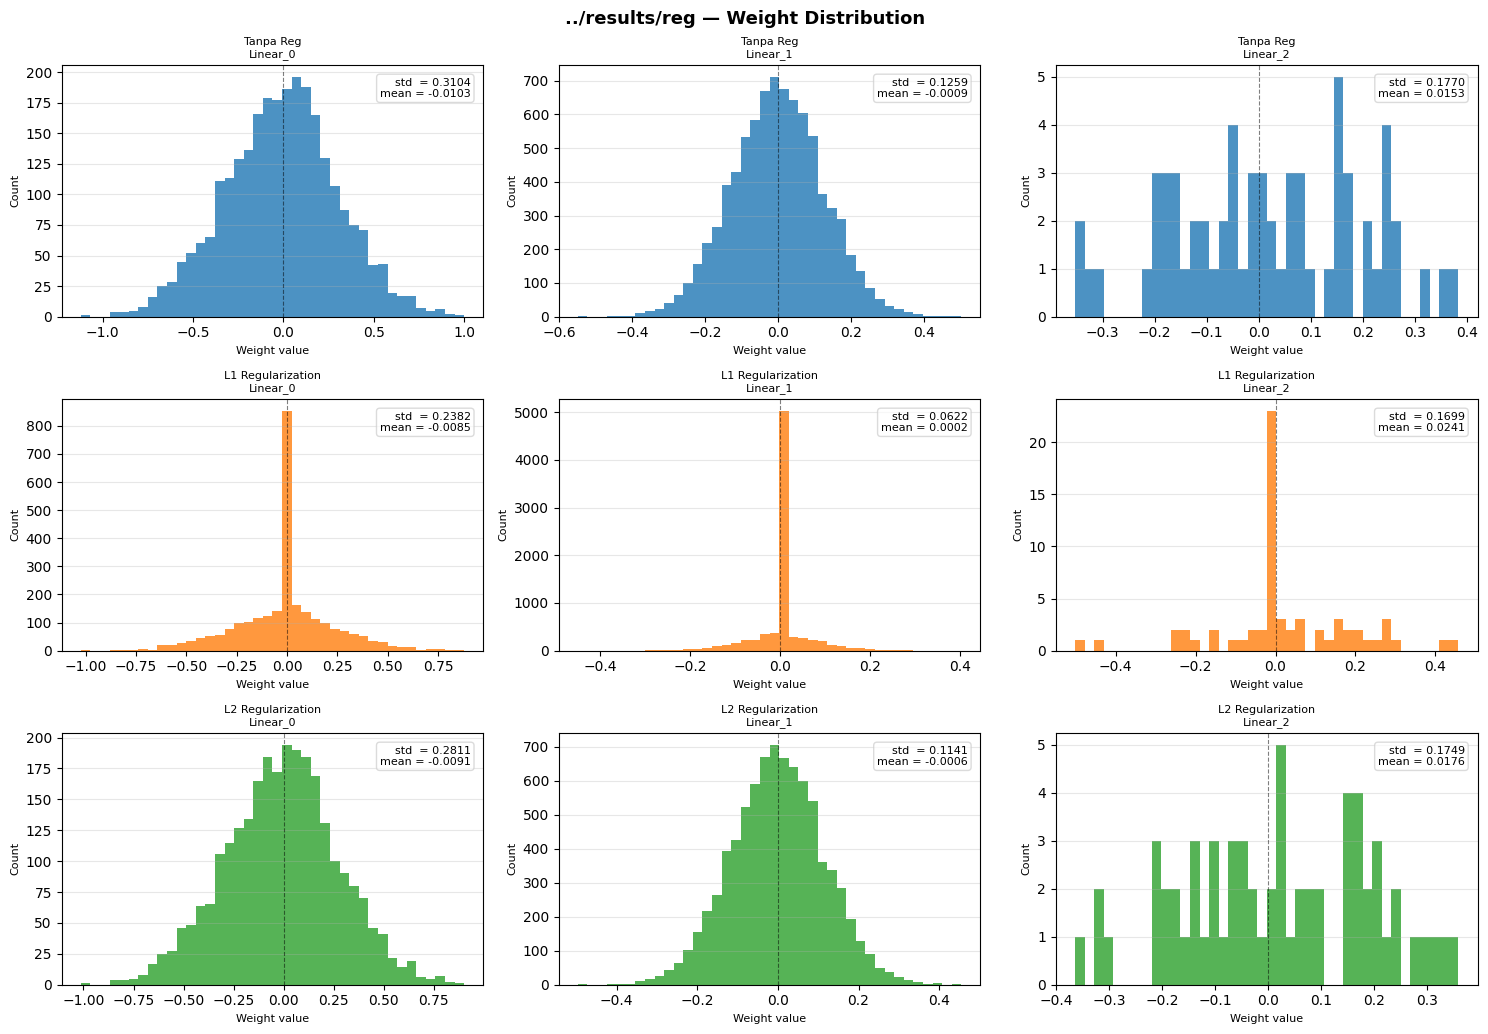

In [7]:
viz.plot_comparison(
    results     = results,
    mode        = 'weights',
    save_prefix = '../results/reg',
)

## Plot : Gradient Distribution

[Visualizer] saved in ../results/reg_grads.png


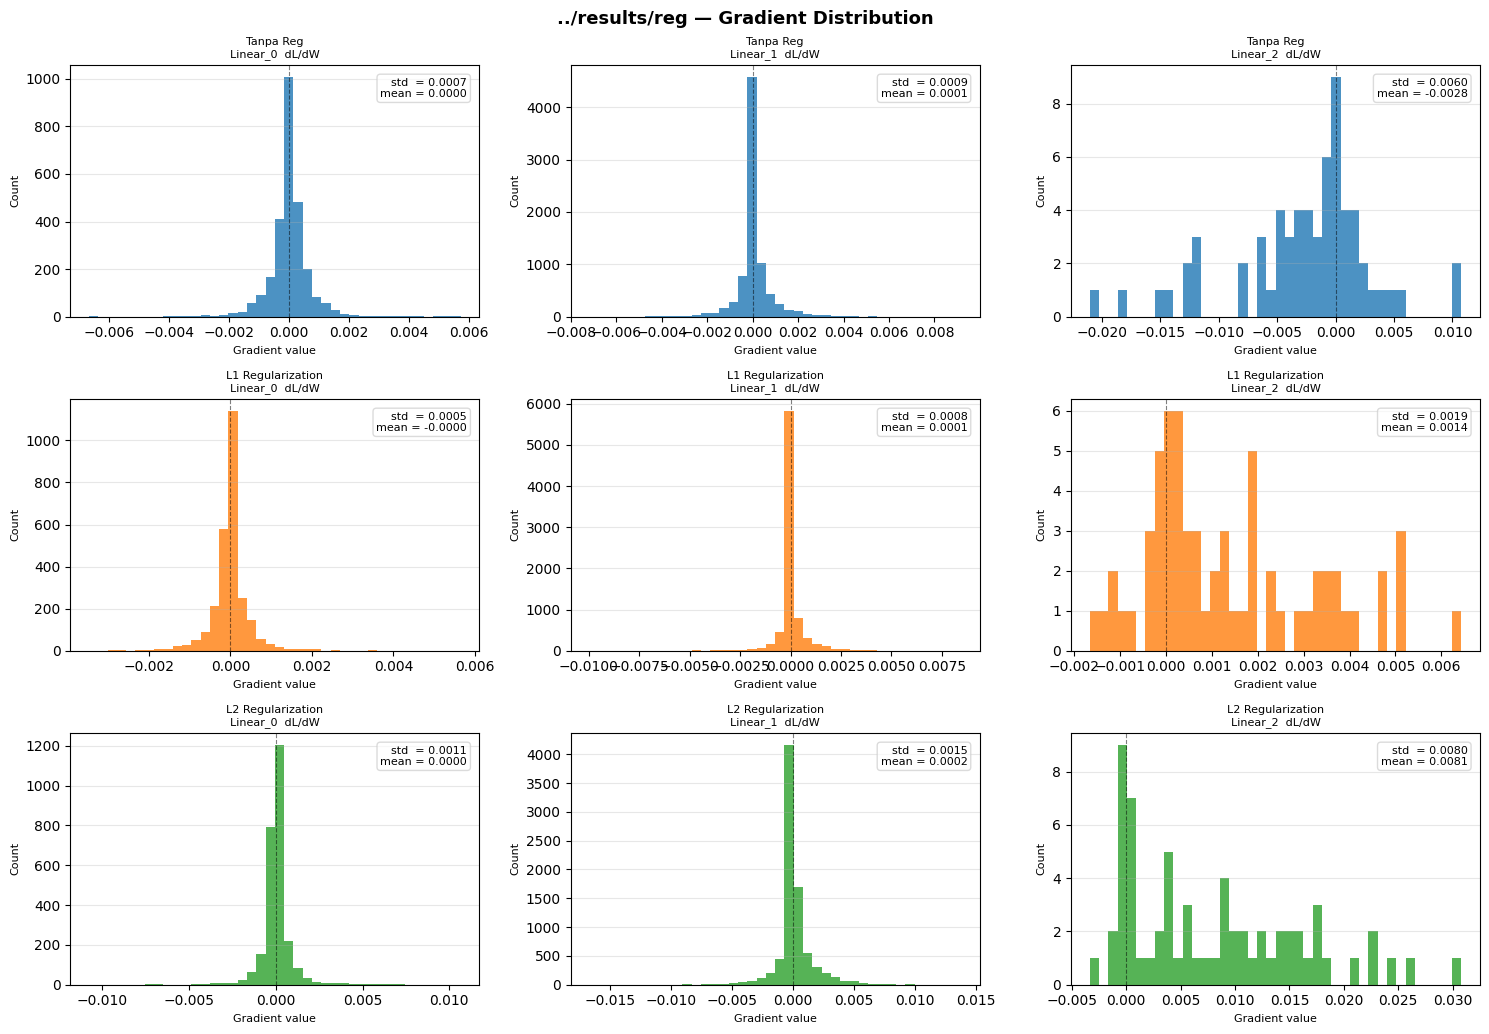

In [8]:
viz.plot_comparison(
    results     = results,
    mode        = 'grads',
    save_prefix = '../results/reg',
    x_ref       = X_test,
    y_ref       = y_test,
)